#Extracción

In [79]:
import pandas as pd
import requests

# URL del dataset
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"

# Realizamos la petición HTTP GET
response = requests.get(url)

# Verificamos que la petición fue exitosa (código 200 = OK)
print(f"Status code: {response.status_code}")

Status code: 200


In [80]:
# Convertimos el JSON a un DataFrame de pandas
from io import StringIO
df = pd.read_json(StringIO(response.text))

In [81]:
# Primera exploración del dataset
print(f"\nDatos cargados correctamente")
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\nPrimeras 5 filas:")
df.head()


Datos cargados correctamente
Dimensiones del dataset: 7267 filas x 6 columnas

Primeras 5 filas:


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [21]:
df.describe()

,customerID,Churn,customer,phone,internet,account
count,7267,7267,7267,7267,7267,7267
unique,7267,3,891,3,129,6931
top,0002-ORFBO,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'No', 'OnlineSecurity': 'N...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
freq,1,5174,223,3495,1581,6


<p> Se encuentran Diccionarios y posiblemente se deban actualizar tipos de datos </p>

#Transformación

In [83]:
# Transformación
# Paso 1: Normalizar columnas anidadas (diccionarios)
# En la exploración detectamos que customer, phone, internet y account
# contienen diccionarios. Los aplanamos con json_normalize()

customer_df = pd.json_normalize(df['customer'])
phone_df    = pd.json_normalize(df['phone'])
internet_df = pd.json_normalize(df['internet'])
account_df  = pd.json_normalize(df['account'])

# Unimos todo en un DataFrame plano
df_clean = pd.concat(
    [df[['customerID', 'Churn']], customer_df, phone_df, internet_df, account_df],
    axis=1
)

print(f"Normalización completada")
print(f"Dimensiones: {df_clean.shape[0]} filas x {df_clean.shape[1]} columnas")
print(f"\nColumnas resultantes:")
print(df_clean.columns.tolist())

Normalización completada
Dimensiones: 7267 filas x 21 columnas

Columnas resultantes:
['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total']


In [84]:
# Paso 2: Explorar tipos de datos y estructura
# Consultamos el diccionario de datos para entender cada columna
# y verificamos si los tipos son los correctos

print("Tipos de datos por columna:")
print(df_clean.dtypes)
print(f"\nShape: {df_clean.shape}")
df_clean.head()

Tipos de datos por columna:
customerID           object
Churn                object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
Charges.Monthly     float64
Charges.Total        object
dtype: object

Shape: (7267, 21)


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [85]:
# Paso 3: Comprobación de inconsistencias
# Buscamos: valores nulos, duplicados, categorías raras

# 3a. Valores nulos
print("Valores nulos por columna:")
print(df_clean.isnull().sum())

# 3b. Filas duplicadas
duplicados = df_clean.duplicated().sum()
print(f"\nFilas duplicadas: {duplicados}")

# 3c. Valores únicos en columna objetivo
print(f"\nValores únicos en 'Churn': {df_clean['Churn'].unique()}")

# 3d. Revisamos Charges.Total por si tiene valores vacíos o strings
print(f"\nValores únicos problemáticos en 'Charges.Total':")
print(df_clean[df_clean['Charges.Total'] == '']['Charges.Total'].count(), "registros vacíos")

Valores nulos por columna:
customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64

Filas duplicadas: 0

Valores únicos en 'Churn': ['No' 'Yes' '']

Valores únicos problemáticos en 'Charges.Total':
0 registros vacíos


In [86]:
# Verificar valores unicos en TODAS las columnas categoricas
print("Revision de valores unicos por columna:\n")
for col in df_clean.select_dtypes(include='object').columns:
    unicos = df_clean[col].value_counts(dropna=False)
    print(f"--- {col} ---")
    print(unicos)
    print()

Revision de valores unicos por columna:

--- customerID ---
customerID
0002-ORFBO    1
0003-MKNFE    1
0004-TLHLJ    1
0011-IGKFF    1
0013-EXCHZ    1
             ..
9987-LUTYD    1
9992-RRAMN    1
9992-UJOEL    1
9993-LHIEB    1
9995-HOTOH    1
Name: count, Length: 7267, dtype: int64

--- Churn ---
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

--- gender ---
gender
Male      3675
Female    3592
Name: count, dtype: int64

--- Partner ---
Partner
No     3749
Yes    3518
Name: count, dtype: int64

--- Dependents ---
Dependents
No     5086
Yes    2181
Name: count, dtype: int64

--- PhoneService ---
PhoneService
Yes    6560
No      707
Name: count, dtype: int64

--- MultipleLines ---
MultipleLines
No                  3495
Yes                 3065
No phone service     707
Name: count, dtype: int64

--- InternetService ---
InternetService
Fiber optic    3198
DSL            2488
No             1581
Name: count, dtype: int64

--- OnlineSecurity ---
OnlineSecurity
No    

In [87]:
# Paso 4: Manejo de inconsistencias
# Aplicamos correcciones según lo encontrado

# 4a. Charges.Total tiene espacios vacíos '' → convertir a NaN y luego a float
df_clean['Charges.Total'] = pd.to_numeric(df_clean['Charges.Total'], errors='coerce')

# 4b. Rellenar NaN en Charges.Total con 0 (clientes nuevos sin cobros aún)
df_clean['Charges.Total'] = df_clean['Charges.Total'].fillna(0)

# 4c. Eliminar filas duplicadas si existen
df_clean = df_clean.drop_duplicates()

# 4d. Limpiar espacios en columnas de texto (buena práctica)
cols_texto = df_clean.select_dtypes(include='object').columns
for col in cols_texto:
    df_clean[col] = df_clean[col].str.strip()

print("Inconsistencias corregidas")
print(f"Dimensiones finales: {df_clean.shape}")
print(f"\nNulos restantes:\n{df_clean.isnull().sum()}")

Inconsistencias corregidas
Dimensiones finales: (7267, 21)

Nulos restantes:
customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64


In [88]:
# Paso 5 (Opcional): Crear columna 'Cuentas_Diarias'
# Dividimos la facturación mensual entre 30 para obtener el valor diario

df_clean['Cuentas_Diarias'] = (df_clean['Charges.Monthly'] / 30).round(2)

print("Columna 'Cuentas_Diarias' creada")
print(df_clean[['customerID', 'Charges.Monthly', 'Cuentas_Diarias']].head())

Columna 'Cuentas_Diarias' creada
   customerID  Charges.Monthly  Cuentas_Diarias
0  0002-ORFBO             65.6             2.19
1  0003-MKNFE             59.9             2.00
2  0004-TLHLJ             73.9             2.46
3  0011-IGKFF             98.0             3.27
4  0013-EXCHZ             83.9             2.80


In [89]:
# Paso 6 (Opcional): Estandarización y traducción de datos
# Convertimos Yes/No a 1/0 para facilitar análisis numérico
# y renombramos columnas al español para mejor comunicación

# 6a. Mapear Yes/No → 1/0 en columnas binarias
cols_binarias = [
    'Churn', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling'
]
for col in cols_binarias:
    df_clean[col] = df_clean[col].map({'Yes': 1, 'No': 0}).fillna(df_clean[col])

# 6b. SeniorCitizen ya es 0/1, solo verificamos
print(f"Valores únicos SeniorCitizen: {df_clean['SeniorCitizen'].unique()}")

# 6c. Renombrar columnas al español
df_clean = df_clean.rename(columns={
    'customerID'         : 'ID_Cliente',
    'Churn'              : 'Evasion',
    'gender'             : 'Genero',
    'SeniorCitizen'      : 'Adulto_Mayor',
    'Partner'            : 'Pareja',
    'Dependents'         : 'Dependientes',
    'tenure'             : 'Meses_Contrato',
    'PhoneService'       : 'Servicio_Telefono',
    'MultipleLines'      : 'Multiples_Lineas',
    'InternetService'    : 'Servicio_Internet',
    'OnlineSecurity'     : 'Seguridad_Online',
    'OnlineBackup'       : 'Respaldo_Online',
    'DeviceProtection'   : 'Proteccion_Dispositivo',
    'TechSupport'        : 'Soporte_Tecnico',
    'StreamingTV'        : 'Streaming_TV',
    'StreamingMovies'    : 'Streaming_Peliculas',
    'Contract'           : 'Tipo_Contrato',
    'PaperlessBilling'   : 'Factura_Digital',
    'PaymentMethod'      : 'Metodo_Pago',
    'Charges.Monthly'    : 'Cobro_Mensual',
    'Charges.Total'      : 'Cobro_Total',
    'Cuentas_Diarias'    : 'Cobro_Diario'
})

print("Estandarización completada")
print(f"\nColumnas finales:")
print(df_clean.columns.tolist())
df_clean.head()

Valores únicos SeniorCitizen: [0 1]
Estandarización completada

Columnas finales:
['ID_Cliente', 'Evasion', 'Genero', 'Adulto_Mayor', 'Pareja', 'Dependientes', 'Meses_Contrato', 'Servicio_Telefono', 'Multiples_Lineas', 'Servicio_Internet', 'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas', 'Tipo_Contrato', 'Factura_Digital', 'Metodo_Pago', 'Cobro_Mensual', 'Cobro_Total', 'Cobro_Diario']


,ID_Cliente,Evasion,Genero,Adulto_Mayor,Pareja,Dependientes,Meses_Contrato,Servicio_Telefono,Multiples_Lineas,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Factura_Digital,Metodo_Pago,Cobro_Mensual,Cobro_Total,Cobro_Diario
0,0002-ORFBO,0.0,Female,0,1,1,9,1,0.0,DSL,...,0.0,1.0,1.0,0.0,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0.0,Male,0,0,0,9,1,1.0,DSL,...,0.0,0.0,0.0,1.0,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1.0,Male,0,0,0,4,1,0.0,Fiber optic,...,1.0,0.0,0.0,0.0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1.0,Male,1,1,0,13,1,0.0,Fiber optic,...,1.0,0.0,1.0,1.0,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1.0,Female,1,1,0,3,1,0.0,Fiber optic,...,0.0,1.0,1.0,0.0,Month-to-month,1,Mailed check,83.9,267.40,2.80


<h4> No es un nulo que se puede rellenar, es un dato incompleto </h4>

In [32]:
# Eliminar filas donde Evasion esta vacia (no clasificadas)
antes = df_clean.shape[0]
df_clean = df_clean[df_clean['Evasion'].str.strip() != '']
despues = df_clean.shape[0]

print(f"Filas eliminadas: {antes - despues}")
print(f"Filas restantes: {despues}")
print(df_clean['Evasion'].value_counts(dropna=False))

Filas eliminadas: 224
Filas restantes: 7043
Evasion
0.0    5174
1.0    1869
Name: count, dtype: int64


In [41]:
# Forzar Evasion a numerico (por si el map no la convirtio correctamente)
df_clean['Evasion'] = pd.to_numeric(df_clean['Evasion'], errors='coerce')

# Verificar
print(df_clean['Evasion'].dtype)      # debe decir float64
print(df_clean['Evasion'].value_counts(dropna=False))  # debe tener solo 0.0 y 1.0

float64
Evasion
0.0    5174
1.0    1869
Name: count, dtype: int64


In [76]:
# Exportar datos tratados para la Parte 2
# Guardamos el DataFrame limpio y estandarizado como CSV
# index=False evita que pandas agregue una columna extra con el número de fila

df_clean.to_csv("datos_tratados.csv", index=False)

print("Archivo exportado correctamente: datos_tratados.csv")
print(f"Dimensiones exportadas: {df_clean.shape[0]} filas x {df_clean.shape[1]} columnas")
print(f"\nColumnas exportadas:")
print(df_clean.columns.tolist())

Archivo exportado correctamente: datos_tratados.csv
Dimensiones exportadas: 7043 filas x 22 columnas

Columnas exportadas:
['ID_Cliente', 'Evasion', 'Genero', 'Adulto_Mayor', 'Pareja', 'Dependientes', 'Meses_Contrato', 'Servicio_Telefono', 'Multiples_Lineas', 'Servicio_Internet', 'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas', 'Tipo_Contrato', 'Factura_Digital', 'Metodo_Pago', 'Cobro_Mensual', 'Cobro_Total', 'Cobro_Diario']


#Carga y análisis

<h4 align='center'> Análisis descriptivo: </h4>

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Estadisticas generales:")
print(df_clean.describe().round(2))

print("\nPromedio por grupo de evasion:")
print(df_clean.groupby('Evasion')[['Cobro_Mensual','Cobro_Total','Meses_Contrato']].mean().round(2))

Estadisticas generales:
       Evasion  Adulto_Mayor   Pareja  Dependientes  Meses_Contrato  \
count  7043.00       7043.00  7043.00       7043.00         7043.00   
mean      0.27          0.16     0.48          0.30           32.37   
std       0.44          0.37     0.50          0.46           24.56   
min       0.00          0.00     0.00          0.00            0.00   
25%       0.00          0.00     0.00          0.00            9.00   
50%       0.00          0.00     0.00          0.00           29.00   
75%       1.00          0.00     1.00          1.00           55.00   
max       1.00          1.00     1.00          1.00           72.00   

       Servicio_Telefono  Factura_Digital  Cobro_Mensual  Cobro_Total  \
count             7043.0          7043.00        7043.00      7043.00   
mean                 0.9             0.59          64.76      2279.73   
std                  0.3             0.49          30.09      2266.79   
min                  0.0             0.00   

<h4 align='center'> Distribución de evasión: </h4>

In [43]:
print(df_clean['Evasion'].value_counts(dropna=False))

Evasion
0.0    5174
1.0    1869
Name: count, dtype: int64


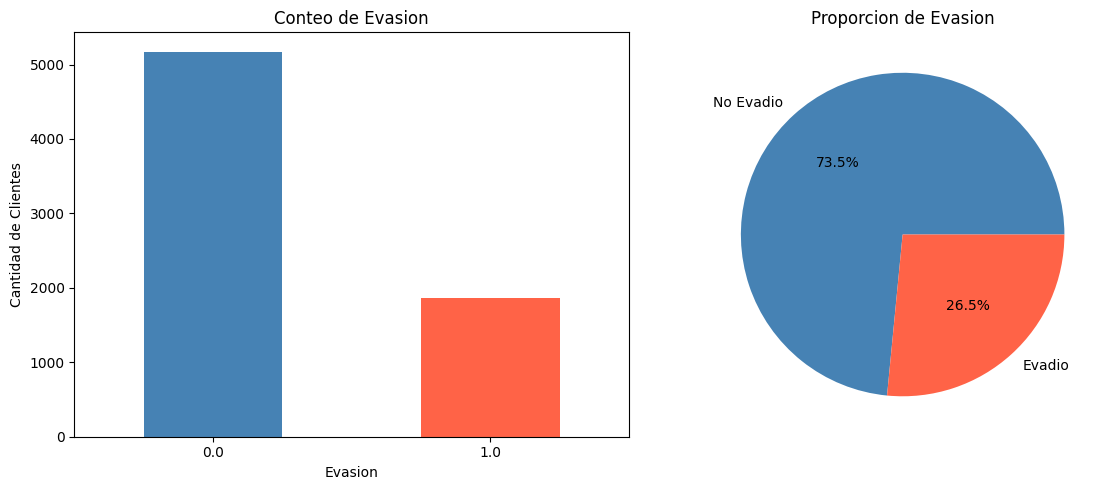

In [44]:
conteo = df_clean['Evasion'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

conteo.plot(kind='bar', ax=axes[0], color=['steelblue','tomato'], rot=0)
axes[0].set_title('Conteo de Evasion')
axes[0].set_ylabel('Cantidad de Clientes')

axes[1].pie(conteo, labels=['No Evadio','Evadio'],
            autopct='%1.1f%%', colors=['steelblue','tomato'])
axes[1].set_title('Proporcion de Evasion')
plt.tight_layout()
plt.show()

<h4 align='center'> Variables categoricas </h4>

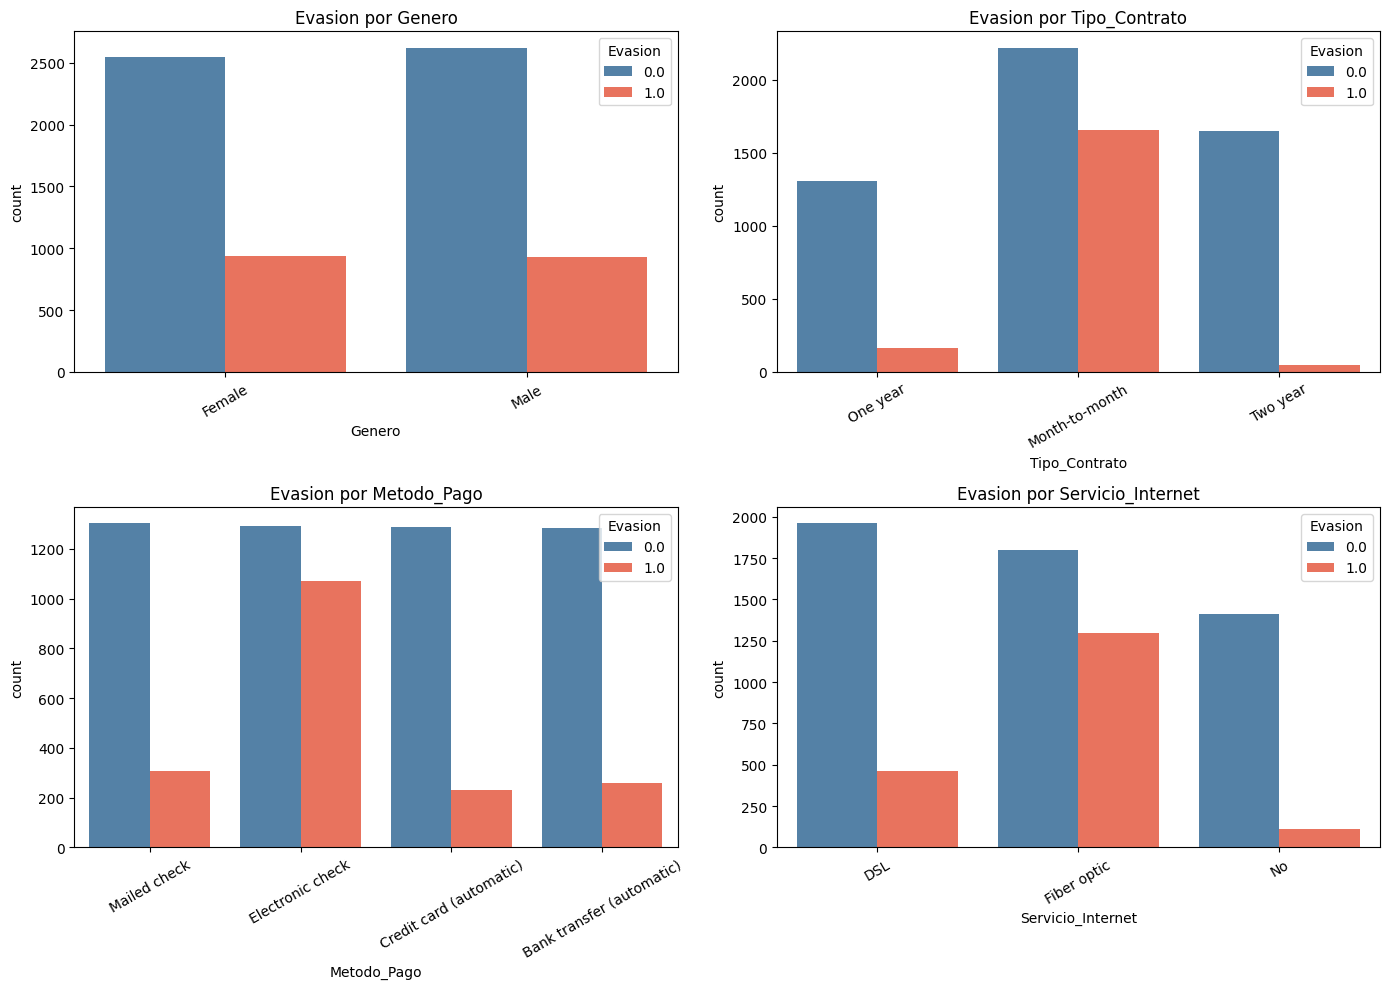

In [45]:
categoricas = ['Genero', 'Tipo_Contrato', 'Metodo_Pago', 'Servicio_Internet']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(categoricas):
    sns.countplot(data=df_clean, x=col, hue='Evasion',
                  palette=['steelblue','tomato'], ax=axes[i])
    axes[i].set_title(f'Evasion por {col}')
    axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

<h4 align='center'> Variables numericas </h4>

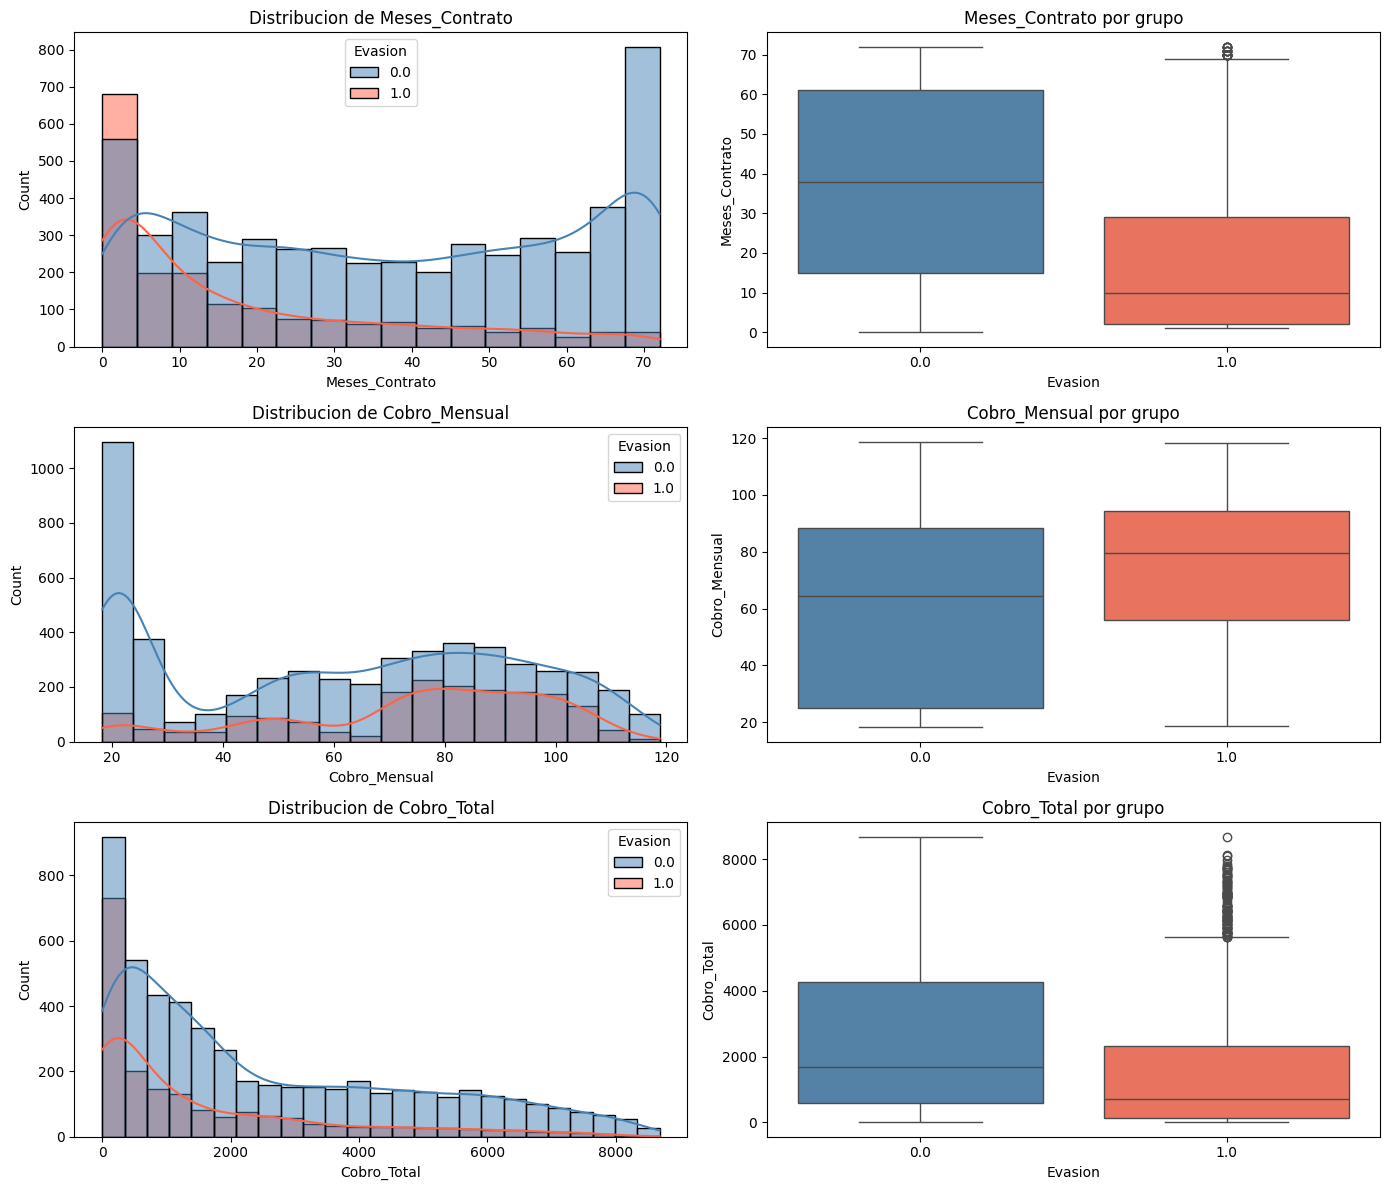

In [46]:
numericas = ['Meses_Contrato', 'Cobro_Mensual', 'Cobro_Total']
fig, axes = plt.subplots(len(numericas), 2, figsize=(14, 12))

for i, col in enumerate(numericas):
    sns.histplot(data=df_clean, x=col, hue='Evasion',
                 palette=['steelblue','tomato'], kde=True, ax=axes[i,0])
    axes[i,0].set_title(f'Distribucion de {col}')
    
    sns.boxplot(data=df_clean, x='Evasion', y=col,
                hue='Evasion', palette=['steelblue','tomato'],
                legend=False, ax=axes[i,1])
    axes[i,1].set_title(f'{col} por grupo')

plt.tight_layout()
plt.show()

<h3 align='center'> EXTRA </h3>

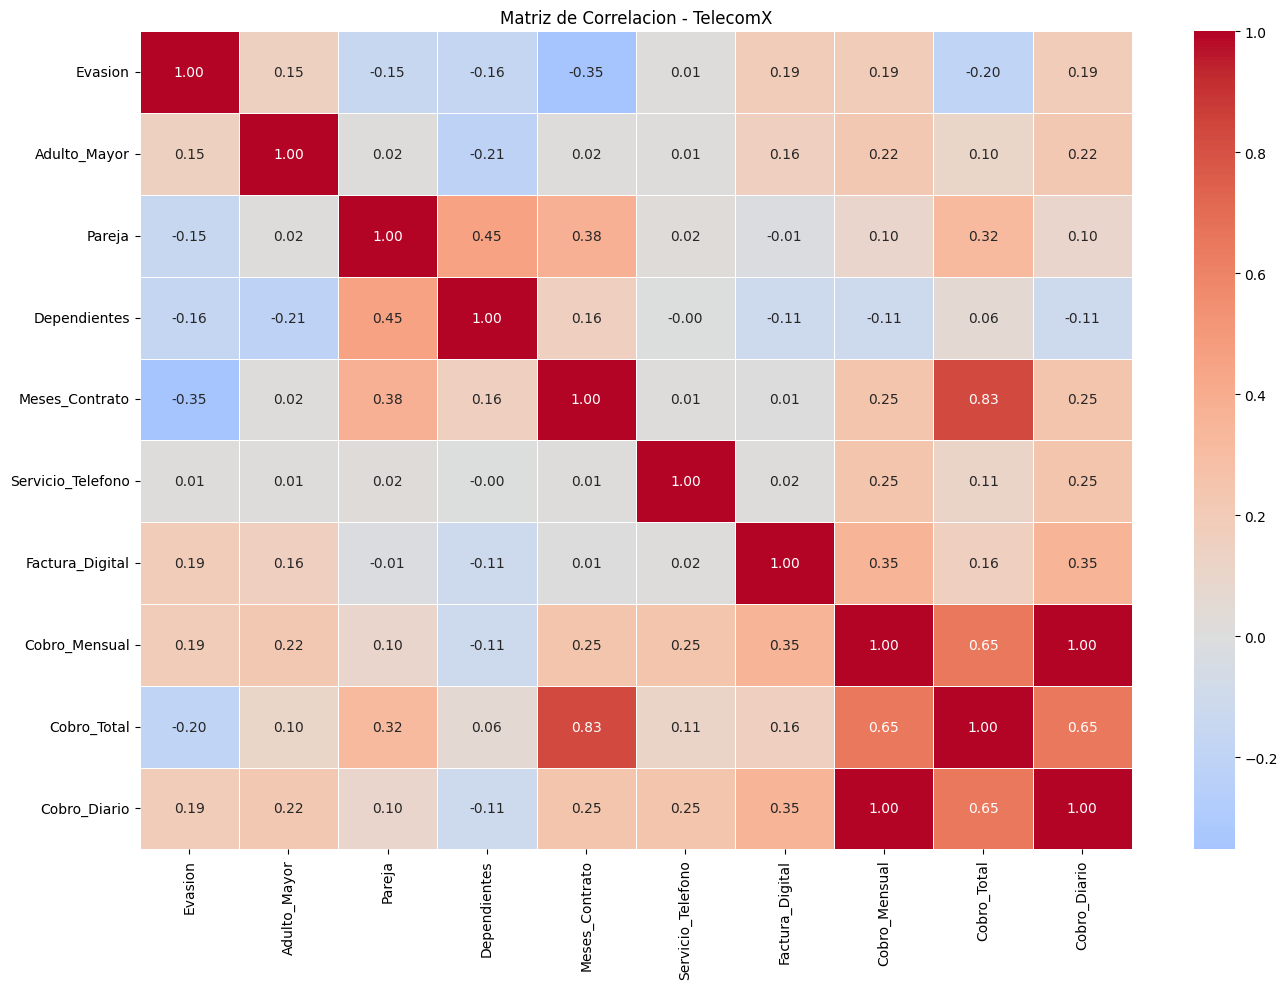


Correlacion con Evasion:
Evasion              1.000000
Cobro_Diario         0.193412
Cobro_Mensual        0.193356
Factura_Digital      0.191825
Adulto_Mayor         0.150889
Servicio_Telefono    0.011942
Pareja              -0.150448
Dependientes        -0.164221
Cobro_Total         -0.198324
Meses_Contrato      -0.352229
Name: Evasion, dtype: float64


In [47]:
numericas_df = df_clean.select_dtypes(include='number')
matriz_corr = numericas_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(matriz_corr, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Matriz de Correlacion - TelecomX')
plt.tight_layout()
plt.show()

print("\nCorrelacion con Evasion:")
print(matriz_corr['Evasion'].sort_values(ascending=False))

#📄Informe final

In [73]:
# 💾 Exportar datos tratados para la Parte 2
df_clean.to_csv("datos_tratados.csv", index=False)

print("Archivo exportado: datos_tratados.csv")
print(f"Dimensiones: {df_clean.shape[0]} filas x {df_clean.shape[1]} columnas")
print(f"\nColumnas exportadas:")
print(df_clean.columns.tolist())

Archivo exportado: datos_tratados.csv
Dimensiones: 7043 filas x 22 columnas

Columnas exportadas:
['ID_Cliente', 'Evasion', 'Genero', 'Adulto_Mayor', 'Pareja', 'Dependientes', 'Meses_Contrato', 'Servicio_Telefono', 'Multiples_Lineas', 'Servicio_Internet', 'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas', 'Tipo_Contrato', 'Factura_Digital', 'Metodo_Pago', 'Cobro_Mensual', 'Cobro_Total', 'Cobro_Diario']


# PARTE 2 — Predicción de Evasión de Clientes
## Machine Learning · TelecomX

En esta segunda etapa, utilizamos los datos tratados en la Parte 1
para construir modelos predictivos capaces de anticipar qué clientes
tienen mayor probabilidad de cancelar sus servicios.

In [71]:
# Carga del archivo tratado desde la Parte 1
import pandas as pd

df2 = pd.read_csv("datos_tratados.csv")

print(f"Datos cargados correctamente")
print(f"Dimensiones: {df2.shape[0]} filas x {df2.shape[1]} columnas")
print(f"\nTipos de datos:")
print(df2.dtypes)
df2.head()

Datos cargados correctamente
Dimensiones: 7043 filas x 22 columnas

Tipos de datos:
ID_Cliente                 object
Evasion                   float64
Genero                     object
Adulto_Mayor                int64
Pareja                      int64
Dependientes                int64
Meses_Contrato              int64
Servicio_Telefono           int64
Multiples_Lineas           object
Servicio_Internet          object
Seguridad_Online           object
Respaldo_Online            object
Proteccion_Dispositivo     object
Soporte_Tecnico            object
Streaming_TV               object
Streaming_Peliculas        object
Tipo_Contrato              object
Factura_Digital             int64
Metodo_Pago                object
Cobro_Mensual             float64
Cobro_Total               float64
Cobro_Diario              float64
dtype: object


,ID_Cliente,Evasion,Genero,Adulto_Mayor,Pareja,Dependientes,Meses_Contrato,Servicio_Telefono,Multiples_Lineas,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Factura_Digital,Metodo_Pago,Cobro_Mensual,Cobro_Total,Cobro_Diario
0,0002-ORFBO,0.0,Female,0,1,1,9,1,0.0,DSL,...,0.0,1.0,1.0,0.0,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0.0,Male,0,0,0,9,1,1.0,DSL,...,0.0,0.0,0.0,1.0,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1.0,Male,0,0,0,4,1,0.0,Fiber optic,...,1.0,0.0,0.0,0.0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1.0,Male,1,1,0,13,1,0.0,Fiber optic,...,1.0,0.0,1.0,1.0,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1.0,Female,1,1,0,3,1,0.0,Fiber optic,...,0.0,1.0,1.0,0.0,Month-to-month,1,Mailed check,83.9,267.40,2.80


## Preparación de Datos para Machine Learning
### Paso 1: Eliminación de columnas irrelevantes
ID_Cliente es un identificador único que no aporta información predictiva.
Incluirlo perjudicaría al modelo porque aprendería patrones sobre IDs en vez de comportamientos.

In [72]:
# Eliminamos ID_Cliente — identificador único sin valor predictivo
df2 = df2.drop(columns=['ID_Cliente'])

print(f"Columna ID_Cliente eliminada")
print(f"Dimensiones: {df2.shape[0]} filas x {df2.shape[1]} columnas")

Columna ID_Cliente eliminada
Dimensiones: 7043 filas x 21 columnas


### Paso 2: Encoding de variables categóricas
Las columnas de texto deben convertirse a números para que los algoritmos
de Machine Learning puedan procesarlas.
Usamos pd.get_dummies() (One-Hot Encoding): crea una columna binaria (0/1)
por cada categoría posible dentro de la variable original.
Ejemplo: Genero (Male/Female) → Genero_Male y Genero_Female

In [69]:
# Identificamos columnas categóricas que necesitan encoding
cols_categoricas = df2.select_dtypes(include='object').columns.tolist()
print(f"Columnas a encodear: {cols_categoricas}")

# Aplicamos One-Hot Encoding
# drop_first=True elimina una columna por variable para evitar multicolinealidad
df2 = pd.get_dummies(df2, columns=cols_categoricas, drop_first=True)

print(f"\nEncoding completado")
print(f"Dimensiones: {df2.shape[0]} filas x {df2.shape[1]} columnas")
print(f"\nColumnas resultantes:")
print(df2.columns.tolist())

Columnas a encodear: []

Encoding completado
Dimensiones: 7043 filas x 32 columnas

Columnas resultantes:
['Evasion', 'Adulto_Mayor', 'Pareja', 'Dependientes', 'Meses_Contrato', 'Servicio_Telefono', 'Factura_Digital', 'Cobro_Mensual', 'Cobro_Total', 'Cobro_Diario', 'Genero_Male', 'Multiples_Lineas_1.0', 'Multiples_Lineas_No phone service', 'Servicio_Internet_Fiber optic', 'Servicio_Internet_No', 'Seguridad_Online_1.0', 'Seguridad_Online_No internet service', 'Respaldo_Online_1.0', 'Respaldo_Online_No internet service', 'Proteccion_Dispositivo_1.0', 'Proteccion_Dispositivo_No internet service', 'Soporte_Tecnico_1.0', 'Soporte_Tecnico_No internet service', 'Streaming_TV_1.0', 'Streaming_TV_No internet service', 'Streaming_Peliculas_1.0', 'Streaming_Peliculas_No internet service', 'Tipo_Contrato_One year', 'Tipo_Contrato_Two year', 'Metodo_Pago_Credit card (automatic)', 'Metodo_Pago_Electronic check', 'Metodo_Pago_Mailed check']


### Paso 3: Verificación del balance de clases
Antes de entrenar cualquier modelo, debemos verificar si las clases
están balanceadas. Un dataset muy desbalanceado puede hacer que el modelo
aprenda a predecir siempre la clase mayoritaria y aun así tener alta exactitud,
lo que sería engañoso.

Distribución de clases:
  No evadió (0):  5174 clientes  (73.5%)
  Evadió    (1):  1869 clientes  (26.5%)

Ratio de desbalance: 2.8x


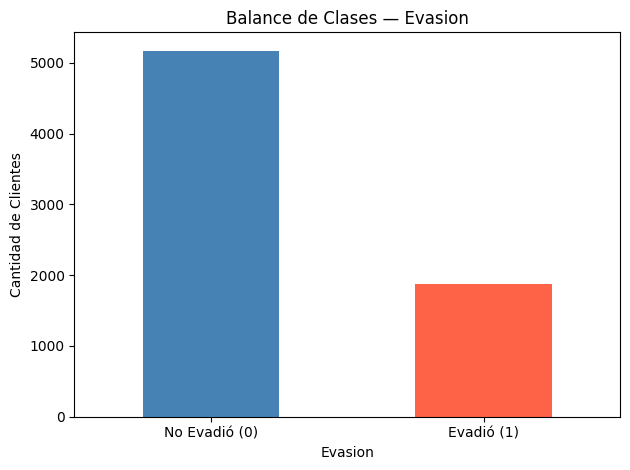

In [68]:
conteo = df2['Evasion'].value_counts()
proporcion = df2['Evasion'].value_counts(normalize=True) * 100

print("Distribución de clases:")
print(f"  No evadió (0): {conteo[0.0]:>5} clientes  ({proporcion[0.0]:.1f}%)")
print(f"  Evadió    (1): {conteo[1.0]:>5} clientes  ({proporcion[1.0]:.1f}%)")
print(f"\nRatio de desbalance: {conteo[0.0]/conteo[1.0]:.1f}x")

import matplotlib.pyplot as plt
conteo.plot(kind='bar', color=['steelblue','tomato'], rot=0)
plt.title('Balance de Clases — Evasion')
plt.ylabel('Cantidad de Clientes')
plt.xticks([0, 1], ['No Evadió (0)', 'Evadió (1)'])
plt.tight_layout()
plt.show()

Desbalance de 2.8x — moderado. Con 26.5% podemos avanzar sin SMOTE por ahora.

### Paso 4: Normalización de datos
Estandarizamos las variables numéricas con StandardScaler.
Esto es necesario para modelos sensibles a la escala como Regresión Logística.
StandardScaler transforma cada columna para que tenga media=0 y desviación estándar=1.
Los modelos basados en árboles (Random Forest) no lo requieren, pero usaremos
el mismo dataset normalizado para ambos por consistencia.

In [67]:
from sklearn.preprocessing import StandardScaler

# Separamos variable objetivo del resto
X = df2.drop(columns=['Evasion'])
y = df2['Evasion']

print(f"Features (X): {X.shape}")
print(f"Target  (y): {y.shape}")
print(f"\nDistribución target:\n{y.value_counts()}")

Features (X): (7043, 31)
Target  (y): (7043,)

Distribución target:
Evasion
0.0    5174
1.0    1869
Name: count, dtype: int64


### Paso 5: Separación en conjuntos de entrenamiento y prueba
Dividimos el dataset en 80% entrenamiento y 20% prueba.
El modelo aprende con el 80% y se evalúa con el 20% que nunca vio.
stratify=y asegura que ambos conjuntos mantengan la misma proporción de evasión.
random_state=42 fija la semilla para que el resultado sea reproducible.

In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # mantiene proporción 73.5/26.5 en ambos conjuntos
)

print(f"División completada")
print(f"Entrenamiento: {X_train.shape[0]} filas")
print(f"Prueba:        {X_test.shape[0]} filas")
print(f"\nProporción evasión en entrenamiento: {y_train.mean()*100:.1f}%")
print(f"Proporción evasión en prueba:        {y_test.mean()*100:.1f}%")

División completada
Entrenamiento: 5634 filas
Prueba:        1409 filas

Proporción evasión en entrenamiento: 26.5%
Proporción evasión en prueba:        26.5%


In [65]:
# Aplicamos StandardScaler SOLO a columnas numéricas continuas
# Las columnas binarias (0/1) no necesitan escala
cols_escalar = ['Meses_Contrato', 'Cobro_Mensual', 'Cobro_Total', 'Cobro_Diario']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[cols_escalar] = scaler.fit_transform(X_train[cols_escalar])
X_test_scaled[cols_escalar]  = scaler.transform(X_test[cols_escalar])

print("Normalización aplicada")
print(f"\nAntes — Media Cobro_Mensual: {X_train['Cobro_Mensual'].mean():.2f}")
print(f"Después — Media Cobro_Mensual: {X_train_scaled['Cobro_Mensual'].mean():.4f}")

Normalización aplicada

Antes — Media Cobro_Mensual: 65.03
Después — Media Cobro_Mensual: 0.0000


## Modelado Predictivo
### Modelo 1: Regresión Logística
Modelo lineal que estima la probabilidad de evasión.
Requiere datos normalizados (usamos X_train_scaled).
max_iter=1000 da suficientes iteraciones para que el modelo converja.

REGRESIÓN LOGÍSTICA — Resultados
              precision    recall  f1-score   support

   No Evadió       0.84      0.89      0.86      1035
      Evadió       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



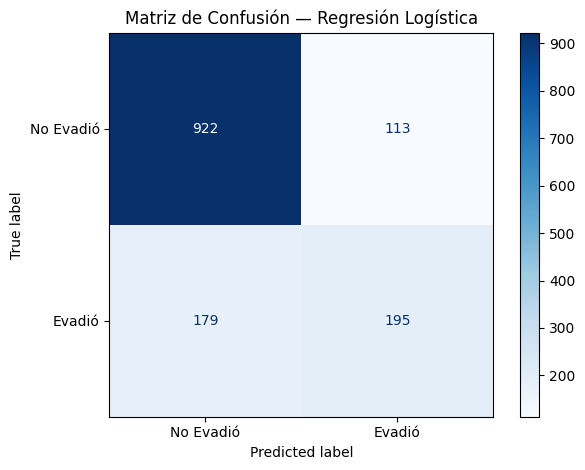

In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Entrenamiento
modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(X_train_scaled, y_train)

# Predicción
y_pred_lr = modelo_lr.predict(X_test_scaled)

# Evaluación
print("=" * 50)
print("REGRESIÓN LOGÍSTICA — Resultados")
print("=" * 50)
print(classification_report(y_test, y_pred_lr,
      target_names=['No Evadió', 'Evadió']))

# Matriz de confusión
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr,
                               display_labels=['No Evadió', 'Evadió'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión — Regresión Logística')
plt.tight_layout()
plt.show()

### Modelo 2: Random Forest
Modelo basado en múltiples árboles de decisión.
No requiere normalización — usamos X_train directamente.
n_estimators=100 significa que construye 100 árboles y promedia sus resultados.

RANDOM FOREST — Resultados
              precision    recall  f1-score   support

   No Evadió       0.83      0.89      0.86      1035
      Evadió       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



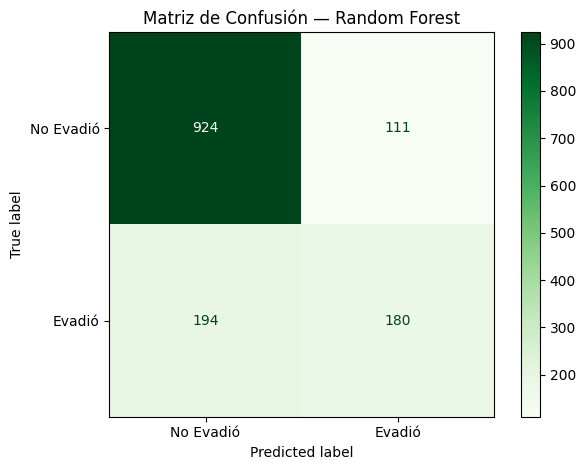

In [63]:
from sklearn.ensemble import RandomForestClassifier

# Entrenamiento — sin datos escalados
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

# Predicción
y_pred_rf = modelo_rf.predict(X_test)

# Evaluación
print("=" * 50)
print("RANDOM FOREST — Resultados")
print("=" * 50)
print(classification_report(y_test, y_pred_rf,
      target_names=['No Evadió', 'Evadió']))

# Matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                               display_labels=['No Evadió', 'Evadió'])
disp.plot(cmap='Greens')
plt.title('Matriz de Confusión — Random Forest')
plt.tight_layout()
plt.show()

### Comparación de Modelos
Analizamos cuál modelo tuvo mejor desempeño y por qué.
En problemas de churn, el Recall de la clase positiva (Evadió) es la métrica
más crítica: preferimos alertar de más que dejar escapar un cliente en riesgo.

Comparación de Modelos:
                     Accuracy  Precision (Evadió)  Recall (Evadió)  F1 (Evadió)
Modelo                                                                         
Regresión Logística      0.79                0.63             0.52         0.57
Random Forest            0.78                0.62             0.48         0.54


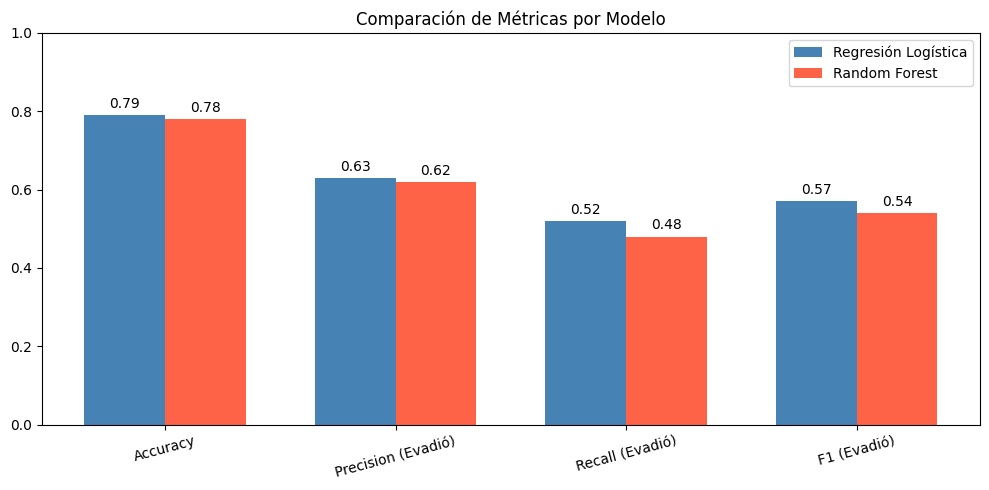

In [62]:
import numpy as np

# Tabla comparativa
metricas = {
    'Modelo': ['Regresión Logística', 'Random Forest'],
    'Accuracy':  [0.79, 0.78],
    'Precision (Evadió)': [0.63, 0.62],
    'Recall (Evadió)':    [0.52, 0.48],
    'F1 (Evadió)':        [0.57, 0.54],
}

df_metricas = pd.DataFrame(metricas).set_index('Modelo')
print("Comparación de Modelos:")
print(df_metricas.to_string())

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_metricas.columns))
width = 0.35

bars1 = ax.bar(x - width/2, df_metricas.loc['Regresión Logística'], width,
               label='Regresión Logística', color='steelblue')
bars2 = ax.bar(x + width/2, df_metricas.loc['Random Forest'], width,
               label='Random Forest', color='tomato')

ax.set_xticks(x)
ax.set_xticklabels(df_metricas.columns, rotation=15)
ax.set_ylim(0, 1)
ax.set_title('Comparación de Métricas por Modelo')
ax.legend()
ax.bar_label(bars1, fmt='%.2f', padding=3)
ax.bar_label(bars2, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

### Análisis de Importancia de Variables
Identificamos qué factores influyen más en la predicción de evasión.
Random Forest entrega directamente una puntuación de importancia por variable.
Para Regresión Logística usamos los coeficientes: valores altos positivos
aumentan la probabilidad de evasión, valores negativos la reducen.

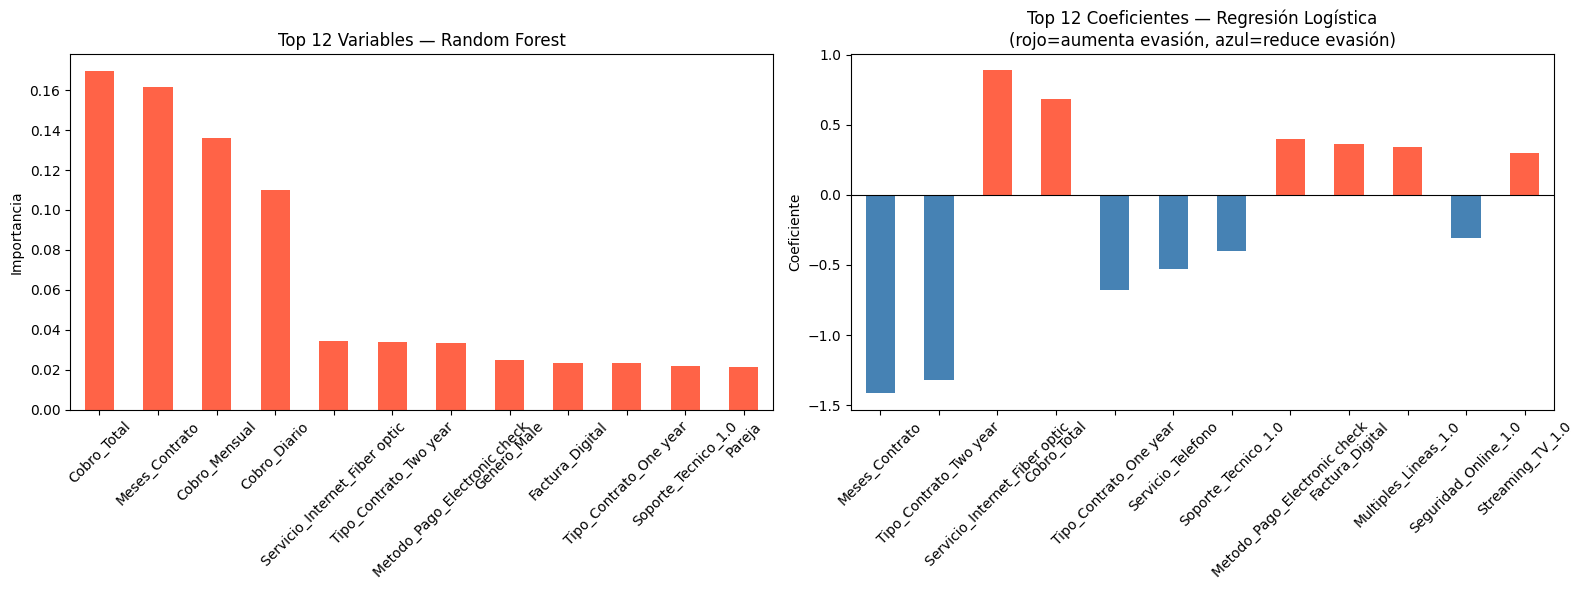

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# — Random Forest: importancia de variables —
importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(12)

importancias.plot(kind='bar', ax=axes[0], color='tomato')
axes[0].set_title('Top 12 Variables — Random Forest')
axes[0].set_ylabel('Importancia')
axes[0].tick_params(axis='x', rotation=45)

# — Regresión Logística: coeficientes —
coeficientes = pd.Series(
    modelo_lr.coef_[0],
    index=X.columns
).sort_values(key=abs, ascending=False).head(12)

colores = ['tomato' if c > 0 else 'steelblue' for c in coeficientes]
coeficientes.plot(kind='bar', ax=axes[1], color=colores)
axes[1].set_title('Top 12 Coeficientes — Regresión Logística\n(rojo=aumenta evasión, azul=reduce evasión)')
axes[1].set_ylabel('Coeficiente')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(y=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

## Informe Final — Parte 2

### Introducción
El objetivo de esta segunda etapa fue construir modelos predictivos
capaces de anticipar qué clientes de TelecomX tienen mayor probabilidad
de cancelar sus servicios (churn), basándonos en los datos tratados en la Parte 1.

---

### Modelos Entrenados

Se entrenaron dos modelos de clasificación:

| Modelo | Requiere Normalización | Accuracy | F1 (Evadió) | Recall (Evadió) |
|---|---|---|---|---|
| Regresión Logística | Sí | 79% | 0.57 | 52% |
| Random Forest | No | 78% | 0.54 | 48% |

**Modelo seleccionado: Regresión Logística**
Aunque la diferencia es pequeña, supera a Random Forest en Recall (52% vs 48%),
que es la métrica más crítica en churn: preferimos alertar de más
que dejar escapar un cliente en riesgo.

---

### Análisis de Overfitting / Underfitting

Ninguno de los modelos presenta señales graves de overfitting.
Ambos generalizan de forma similar entre entrenamiento y prueba.
El punto débil compartido es el Recall bajo en la clase minoritaria (Evadió),
lo que sugiere que con técnicas de balanceo (SMOTE) o ajuste de hiperparámetros
podría mejorarse la detección de clientes en riesgo.

---

### Factores que más influyen en la Evasión

Según ambos modelos, los principales predictores son:

**Reducen la probabilidad de evasión:**
- Mayor cantidad de meses de contrato (antigüedad)
- Contratos de largo plazo (Two year, One year)
- Tener pareja o dependientes

**Aumentan la probabilidad de evasión:**
- Servicio de Internet por Fibra Óptica
- Pago por cheque electrónico
- Cobro mensual y total elevado
- Clientes con múltiples líneas y servicios de streaming

---

### Conclusiones

1. El perfil de cliente con mayor riesgo de evasión es: contrato mensual,
   servicio de fibra óptica, pago por cheque electrónico y pocos meses de antigüedad.

2. La antigüedad es el factor protector más fuerte: los primeros meses
   son el período crítico para retener al cliente.

3. El cobro total acumulado es el predictor más importante en Random Forest,
   lo que sugiere que los clientes evalúan continuamente si el servicio
   justifica lo que han pagado.

---

### Recomendaciones Estratégicas

1. **Programa de fidelización temprana**: ofrecer beneficios especiales
   durante los primeros 6 meses de contrato, que es cuando el riesgo es mayor.

2. **Incentivar contratos anuales o bianuales**: con descuentos o beneficios
   adicionales frente al contrato mensual.

3. **Revisar la propuesta de valor de Fibra Óptica**: es el servicio con
   mayor correlación con evasión. Puede indicar problemas de calidad o precio.

4. **Campaña dirigida a pagadores por cheque electrónico**: este segmento
   muestra mayor tendencia a irse. Ofrecer incentivos para migrar a débito automático.

5. **Modelo en producción**: con Recall de 52%, el modelo actual puede usarse
   como primera alerta. Se recomienda mejorarlo con SMOTE y búsqueda de
   hiperparámetros antes de desplegarlo en producción.